In [1]:
from __future__ import annotations

import argparse
import json
from pathlib import Path
from typing import Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================== DEFAULT CONFIGURATION ====================
DEFAULT_RECORDS_DIR = Path("records")
DEFAULT_START_ROUND = 0       # inclusive
DEFAULT_END_ROUND = None      # exclusive, None = all rounds
DEFAULT_FL_METRIC = "acc"     # acc, loss, auc, f1
# ===============================================================


In [2]:
def load_protocol_data(protocol_dir: Path, start_round: int, end_round: Optional[int]) -> Tuple[pd.DataFrame, str, int]:
    """Load CSV and extract protocol name and param count."""
    df = pd.read_csv(protocol_dir / "compression_records.csv")

    # Filter rounds
    df = df[df["round_id"] >= start_round]
    if end_round is not None:
        df = df[df["round_id"] < end_round]

    # Get protocol name
    config_path = protocol_dir / "fl_config.json"
    protocol_name = protocol_dir.name
    if config_path.exists():
        with open(config_path) as f:
            protocol_name = json.load(f).get("codec", protocol_name)

    param_count = int(df["model_size"].iloc[0])
    return df, protocol_name, param_count


def plot_rate_distortion(all_protocols: Dict[str, pd.DataFrame], exclude=[]) -> None:
    """Plot WMAPE vs prior_rate with meta bits annotation."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_protocols)))

    for idx, (name, df) in enumerate(all_protocols.items()):
        if name in exclude:
            print(f"⚠ Skipped {name}: excluded")
            continue
        # Compute averages
        wmape = df["wmape"].mean()
        rate = df.get("prior_rate", df.get("entropy_real_rate")).mean()

        if 'meta_data_size' in df.keys():
            meta_bits = (df["meta_data_size"].mean() * 8 * 1024 * 1024) / (df["model_size"].iloc[0])
        else:
            meta_bits = 0.0

        ax.scatter(rate, wmape, s=150, alpha=0.8, color=colors[idx],
                  edgecolors="black", linewidth=1, label=name, zorder=3)

        if meta_bits > 0.001:
            ax.annotate(f"{meta_bits:.3f}", xy=(rate, wmape), xytext=(8, -8),
                       textcoords="offset points", fontsize=8, alpha=0.6, style="italic")

    ax.set_xlabel("Prior Rate (bits/param)", fontsize=13, fontweight="bold")
    ax.set_ylabel("WMAPE (Distortion)", fontsize=13, fontweight="bold")
    ax.set_title("Rate-Distortion Curve", fontsize=14, fontweight="bold", pad=15)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle="--")
    plt.tight_layout()
    plt.show()


def plot_fl_progress(all_protocols: Dict[str, pd.DataFrame], metric: str, exclude=[]) -> None:
    """Plot FL progress: thin worker lines + bold global line."""
    fig, ax = plt.subplots(figsize=(13, 6), dpi=100)
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_protocols)))

    for idx, (name, df) in enumerate(all_protocols.items()):
        if name in exclude:
            print(f"⚠ Skipped {name}: excluded")
            continue
        worker_col = f"test_{metric}"
        global_col = f"global_eval_{metric}"

        if worker_col not in df.columns or global_col not in df.columns:
            print(f"⚠ Skipped {name}: missing {metric} columns")
            continue

        # Workers: round_id as-is (starts at 0)
        for client_id in df["client_id"].unique():
            client_df = df[df["client_id"] == client_id]
            ax.plot(client_df["round_id"], client_df[worker_col],
                   color=colors[idx], alpha=0.15, linewidth=1, zorder=1)

        # Global: shift by -1 (evaluation happens before round updates)
        global_df = df.groupby("round_id")[global_col].first().reset_index()
        ax.plot(global_df["round_id"] - 1, global_df[global_col],
               color=colors[idx], alpha=0.9, linewidth=2.5, label=name, zorder=2)

    ax.set_xlabel("Round", fontsize=13, fontweight="bold")
    ax.set_ylabel(metric.upper(), fontsize=13, fontweight="bold")
    ax.set_title(f"FL Progress: {metric.upper()}\n(thin=workers, bold=global)",
                fontsize=14, fontweight="bold", pad=15)
    ax.legend(loc="best", framealpha=0.95)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.set_xlim(left=-1)  # Show pre-training global eval
    plt.tight_layout()
    plt.show()


def load_all_protocols(records_dir: Path, start_round: int=0, end_round: Optional[int]=None,
                       exclude: list = []) -> Dict[str, pd.DataFrame]:
    """Load all protocol CSVs from records_dir."""
    protocols = {}

    for run_dir in sorted(records_dir.iterdir()):
        if not run_dir.is_dir() or not (run_dir / "compression_records.csv").exists():
            continue

        try:
            df, name, _ = load_protocol_data(run_dir, start_round, end_round)

            if name in exclude or "wmape" not in df.columns:
                continue

            protocols[name] = df
            print(f"✓ {name:20s} | {df['round_id'].nunique()} rounds × {df['client_id'].nunique()} clients")

        except Exception as e:
            print(f"✗ Skipped {run_dir.name}: {e}")

    print(f"\nLoaded {len(protocols)} protocol(s)\n")
    return protocols


def print_meta_rates(all_protocols: Dict[str, pd.DataFrame]) -> None:
    """Print meta overhead in bits/param for each protocol."""
    print("\n" + "="*50)
    print("Meta Overhead (bits/param)")
    print("="*50)

    for name, df in all_protocols.items():
        if 'meta_data_size' not in df.columns:
            print(f"{name:20s} | No meta data")
            continue

        meta_bits = (df["meta_data_size"].mean() * 8 * 1024 * 1024) / (df["model_size"].iloc[0])
        print(f"{name:20s} | {meta_bits:8.4f}")

    print("="*50 + "\n")


✓ 5_split_codec        | 30 rounds × 5 clients
✓ cancer               | 33 rounds × 5 clients
✓ cancer_binary        | 17 rounds × 5 clients
✓ non_wz_learned       | 50 rounds × 5 clients
✓ cancer_w_outlier     | 50 rounds × 5 clients
✓ cancer_basic_norm    | 33 rounds × 5 clients
✓ 2_split_codec        | 50 rounds × 5 clients
✓ 3_split_codec        | 50 rounds × 5 clients
✓ identity             | 50 rounds × 5 clients
✓ non_wz_learned_binary | 16 rounds × 5 clients

Loaded 10 protocol(s)

⚠ Skipped identity: excluded


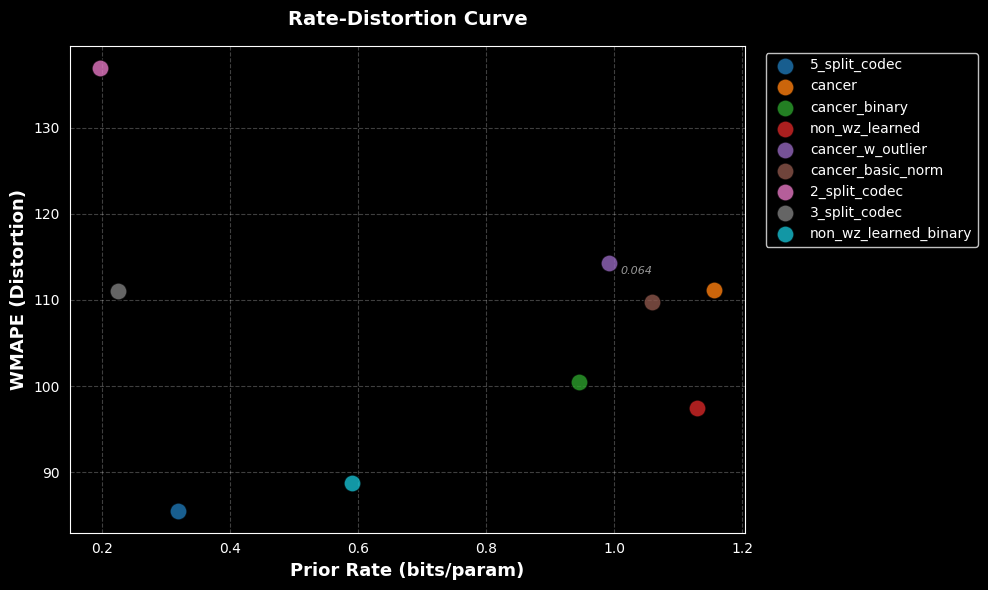

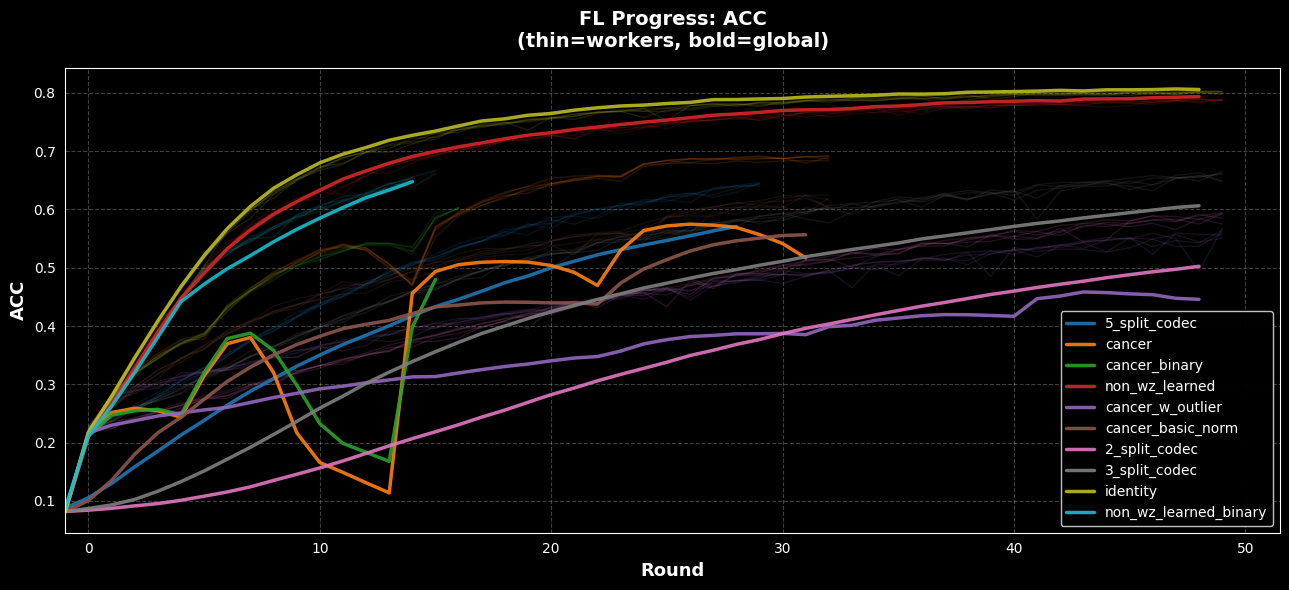

In [4]:
# Load all protocols from records directory
all_protocols = load_all_protocols(
    records_dir=Path("../records"),
    # start_round=6,           # Start from round 0
    # end_round=15,          # Include all rounds (or set a limit like 50)
    # exclude=['identity']     # Skip specific protocols
)
# print_meta_rates(all_protocols)

# Plot compression efficiency
plot_rate_distortion(all_protocols, exclude=['identity'])

# Plot training progress (choose metric: acc, loss, auc, f1)
plot_fl_progress(all_protocols, metric="acc")
